In [1]:
from datetime import datetime
from arcgis.features import FeatureCollection, FeatureSet
from arcgis.gis import Item
from arcgis.geoprocessing._job import GPJob
from arcgis.gis import GIS

In [2]:
from arcgis.gis import GIS
gis = GIS('https://www.arcgis.com', 'arcgis_python', 'amazing_arcgis_123', verify_cert=False)

In [3]:
from arcgis.features.summarize_data import summarize_center_and_dispersion

In [4]:
item = gis.content.get('af7568d8579048f7b42e534891824029')

<Item title:"Recent Earthquakes (Mature Support)" type:Map Image Layer owner:esri>
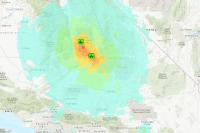

In [5]:
item

In [6]:
quake = item.layers[10]

## Summarize C&D - sync, output service

In [7]:
from datetime import datetime
item = summarize_center_and_dispersion(analysis_layer=quake,
                                summarize_type=["CentralFeature","MeanCenter"],
                                ellipse_size='2 standard deviations',
                                weight_field='mag',
                                group_field='magType',
                                output_name='test dffgvrdfbdffbg' + str(datetime.now().microsecond))

In [8]:
assert isinstance(item, Item)

In [9]:
item.delete()

True

## Summarize C&D - sync, output FC

In [10]:
result = summarize_center_and_dispersion(analysis_layer=quake,
                                summarize_type=["CentralFeature","MeanCenter"],
                                weight_field='mag',
                                group_field='magType')

In [11]:
assert isinstance(result, dict)
assert isinstance(result['central_feature_result_layer'], FeatureCollection)
assert isinstance(result['mean_center_result_layer'], FeatureCollection)